In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
latent_dim = 64

encoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, strides=2, activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=3, strides=2, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(latent_dim, activation='relu'),
])


In [ ]:
decoder = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 64, activation='relu'),
    layers.Reshape((7, 7, 64)),
    layers.Conv2DTranspose(64, kernel_size=3, strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(1, kernel_size=3, activation='sigmoid', padding='same')
])


In [ ]:
# Define the input shape
input_img = layers.Input(shape=(28, 28, 1))

# Pass the input through the encoder
encoded_output = encoder(input_img)

# Pass the encoded output through the decoder
decoded_output = decoder(encoded_output)

# Create the autoencoder model
autoencoder = models.Model(inputs=input_img, outputs=decoded_output)

# Compile the autoencoder model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.3293 - val_loss: 0.1153
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.1050 - val_loss: 0.0861
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0851 - val_loss: 0.0793
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0793 - val_loss: 0.0763
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0761 - val_loss: 0.0747
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0744 - val_loss: 0.0726
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0727 - val_loss: 0.0715
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0719 - val_loss: 0.0706
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0710 - val_loss: 0.0704
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0705 - val_loss: 0.0704
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0703 - val_loss: 0.0692
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


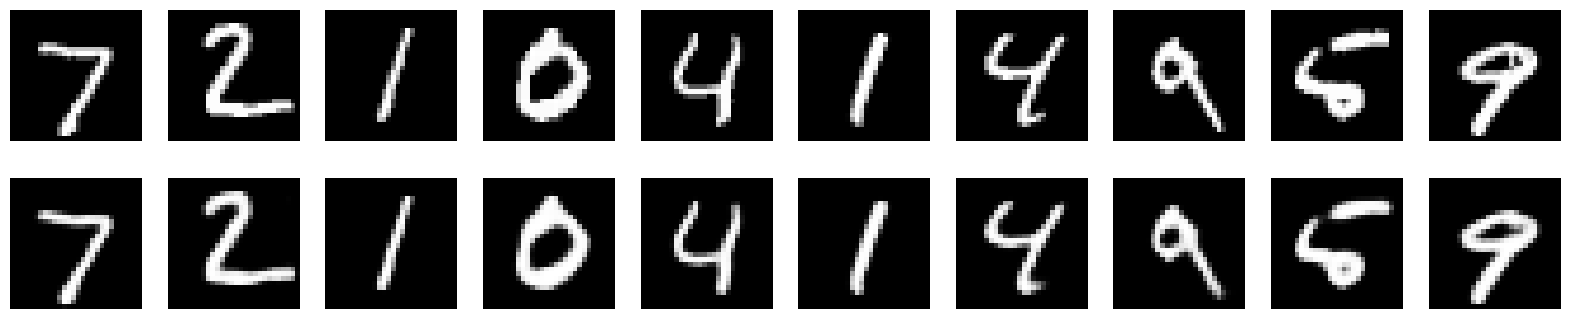

In [ ]:
# Encode and decode test images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Display original and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Display reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.show()
